<a href="https://colab.research.google.com/github/SamalaUjwal/SpamMailDetector/blob/main/SpamMailDetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [133]:
df = pd.read_csv('https://raw.githubusercontent.com/SamalaUjwal/SpamMailDetector/main/mail_data.csv', sep=',', names=['Category', 'Message'])
# Drop the first row which was the original header read as data
df = df.iloc[1:].reset_index(drop=True)
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [134]:
print(df.shape)
print(df.info())
print(df['Category'].value_counts())

(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
Category
ham     4825
spam     747
Name: count, dtype: int64


In [135]:
df.isnull().sum()

,0
Category,0
Message,0


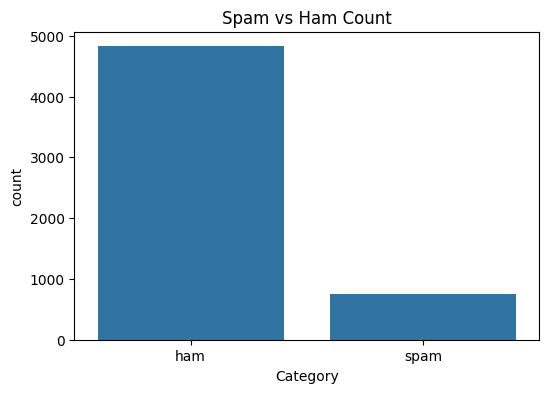

In [136]:
plt.figure(figsize=(6,4))
sns.countplot(x='Category', data=df)
plt.title("Spam vs Ham Count")
plt.show()

In [137]:
df['Category_num'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,Category,Message,Category_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [138]:
X = df['Message']
y = df['Category_num']

In [139]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [140]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df = 1, lowercase=True, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# convert y_train and y_test values as integers

y_train = y_train.astype('int')
y_test = y_test.astype('int')

In [141]:
print(X_train)

184                              He will, you guys close?
2171    CAN I PLEASE COME UP NOW IMIN TOWN.DONTMATTER ...
5422              Ok k..sry i knw 2 siva..tats y i askd..
4113                            I'll see, but prolly yeah
4588    I'll see if I can swing by in a bit, got some ...
                              ...                        
1932                  What pa tell me.. I went to bath:-)
5316                         Jus finish watching tv... U?
2309    Moby Pub Quiz.Win a £100 High Street prize if ...
1904    Free entry in 2 a weekly comp for a chance to ...
762     We are at grandmas. Oh dear, u still ill? I fe...
Name: Message, Length: 4457, dtype: object


In [142]:
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34664 stored elements and shape (4457, 7398)>
  Coords	Values
  (0, 3187)	0.6654771281826798
  (0, 1803)	0.7464182419165099
  (1, 1860)	0.12835575075851152
  (1, 3509)	0.2645075551907188
  (1, 6697)	0.1866083170698886
  (1, 2355)	0.2645075551907188
  (1, 6895)	0.2645075551907188
  (1, 4806)	0.2645075551907188
  (1, 3744)	0.11453521007962277
  (1, 5374)	0.2645075551907188
  (1, 387)	0.2645075551907188
  (1, 2356)	0.2645075551907188
  (1, 2354)	0.2645075551907188
  (1, 4497)	0.2645075551907188
  (1, 6537)	0.2645075551907188
  (1, 3633)	0.2645075551907188
  (1, 3517)	0.19168186204354545
  (1, 6654)	0.2645075551907188
  (1, 400)	0.24345620884965127
  (2, 4726)	0.22420904004227302
  (2, 6172)	0.4447471289878994
  (2, 3832)	0.3886221843200966
  (2, 5952)	0.4607081074843352
  (2, 6441)	0.48320384319846865
  (2, 1070)	0.39391011803589404
  :	:
  (4455, 2222)	0.21593562238191955
  (4455, 7181)	0.18085114829016455
  (4455, 7119)	0.219

In [143]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [144]:
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [145]:
# prediction on training data
from sklearn.metrics import accuracy_score
prediction_on_training_data = model.predict(X_train_tfidf)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)

In [146]:
print('Accuracy on training data : ', accuracy_on_training_data)

Accuracy on training data :  0.9692618353152345


In [147]:
# prediction on test data

prediction_on_test_data = model.predict(X_test_tfidf)
accuracy_on_test_data = accuracy_score(y_test, prediction_on_test_data)

In [148]:
print('Accuracy on test data : ', accuracy_on_test_data)

Accuracy on test data :  0.9668161434977578


In [149]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, prediction_on_test_data)

print(cm)

[[966   0]
 [ 37 112]]


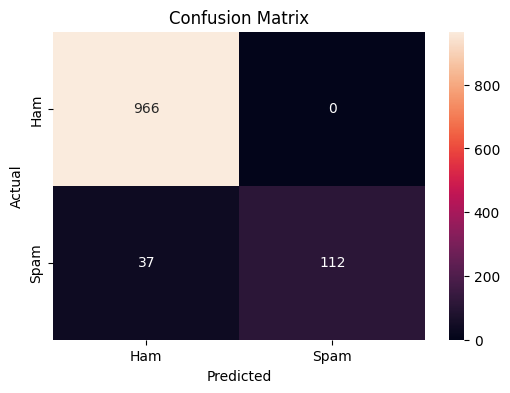

In [150]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [151]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction_on_test_data, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [152]:
input_mail = ["I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times"]

# convert text to feature vectors
input_data_features = tfidf.transform(input_mail)

# making prediction

prediction = model.predict(input_data_features)
print(prediction)


if (prediction[0]==1):
  print('Spam mail')

else:
  print('Ham mail')

[0]
Ham mail


In [153]:
import pickle

pickle.dump(model, open("spam_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.
